# 04 – Benchmarking Regression Implementations

This notebook compares the time and memory cost of the symbolic (naïve) and numerical (optimized) regression routines provided by `regkit`.

We benchmark four scenarios that vary the number of sample points and the polynomial degree. Each configuration is evaluated with the symbolic construction (`regression_naive`), the optimized block solve (`regression_optimized`), and the out-of-core variant (`regression_largeP`). For every run we record wall-clock time and peak memory usage using `tracemalloc`.

In [1]:
# Installing needed dependencies
!pip install -q numpy pandas matplotlib seaborn ipywidgets && echo "Installed dependencies successfully."

# Install our regkit package in editable mode
# !python -m pip install -q -e .. && echo "Installed regkit package successfully."

# Alternatively, if you want to install in regular mode, uncomment the following line:
!python -m pip install -q .. && echo "Installed regkit package successfully."

Installed dependencies successfully.
Installed regkit package successfully.


In [2]:
import gc
import time
import tracemalloc
from collections import defaultdict
from itertools import product

import matplotlib.pyplot as plt
import numpy as np

from regkit.datasets import gen_exploration_dataset
from regkit.naive import regression_naive
from regkit.optimized import regression_largeP, regression_optimized

In [3]:
plt.style.use('seaborn-v0_8-muted')

POINT_LEVELS = [200, 1500]
DEGREE_LEVELS = [2, 4]

IMPLEMENTATIONS = {
    'Naïve (symbolic)': lambda X, Y, degree: regression_naive(X, Y, degree, quiet=True),
    'Optimized block solve': lambda X, Y, degree: regression_optimized(X, Y, degree, quiet=True),
    'Out-of-core largeP': lambda X, Y, degree: regression_largeP(X, Y, degree, quiet=True),
}

def make_dataset(num_points: int, *, n: int = 3, m: int = 3, seed: int = 123, noise: float = 0.02):
    '''Return arrays shaped (P, n) and (P, m) for regression.'''
    X_raw, Y_raw = gen_exploration_dataset(num_points, n=n, m=m, seed=seed, noise=noise)
    return X_raw.T, Y_raw.T

In [4]:
def run_once(func, X, Y, degree):
    '''Execute a regression implementation and discard outputs.'''
    _ = func(X, Y, degree)

def benchmark(func, X, Y, degree, *, repeat: int = 3):
    '''Return (mean_time_s, std_time_s, mean_peak_mb).'''
    timings: list[float] = []
    peaks: list[float] = []
    run_once(func, X, Y, degree)  # warm-up
    for _ in range(repeat):
        gc.collect()
        tracemalloc.start()
        start = time.perf_counter()
        run_once(func, X, Y, degree)
        elapsed = time.perf_counter() - start
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        timings.append(elapsed)
        peaks.append(peak / 1e6)
    return float(np.mean(timings)), float(np.std(timings)), float(np.mean(peaks))

In [5]:
records: list[dict[str, float | int | str]] = []
for num_points, degree in product(POINT_LEVELS, DEGREE_LEVELS):
    X, Y = make_dataset(num_points)
    repeats = 3 if num_points <= 500 else 2
    for name, func in IMPLEMENTATIONS.items():
        mean_t, std_t, mean_mem = benchmark(func, X, Y, degree, repeat=repeats)
        records.append(
            {
                'Implementation': name,
                'Points': num_points,
                'Degree': degree,
                'Repeat': repeats,
                'Mean time [s]': mean_t,
                'Std time [s]': std_t,
                'Peak memory [MB]': mean_mem,
            }
        )
records

[{'Implementation': 'Naïve (symbolic)',
  'Points': 200,
  'Degree': 2,
  'Repeat': 3,
  'Mean time [s]': 3.4253530236666925,
  'Std time [s]': 0.08187604570602644,
  'Peak memory [MB]': 0.648764},
 {'Implementation': 'Optimized block solve',
  'Points': 200,
  'Degree': 2,
  'Repeat': 3,
  'Mean time [s]': 0.001789956666660449,
  'Std time [s]': 3.57227364290295e-05,
  'Peak memory [MB]': 0.034775999999999994},
 {'Implementation': 'Out-of-core largeP',
  'Points': 200,
  'Degree': 2,
  'Repeat': 3,
  'Mean time [s]': 0.0018053866666984202,
  'Std time [s]': 2.9526792213983556e-05,
  'Peak memory [MB]': 0.03599733333333333},
 {'Implementation': 'Naïve (symbolic)',
  'Points': 200,
  'Degree': 4,
  'Repeat': 3,
  'Mean time [s]': 38.735580719333335,
  'Std time [s]': 0.36702571593904965,
  'Peak memory [MB]': 2.0985816666666666},
 {'Implementation': 'Optimized block solve',
  'Points': 200,
  'Degree': 4,
  'Repeat': 3,
  'Mean time [s]': 0.002259767333346948,
  'Std time [s]': 4.609830

In [5]:
try:
    import pandas as pd
except ImportError:
    pd = None

if pd is not None:
    df = pd.DataFrame(records)
    display(
        df.pivot_table(
            index=['Points', 'Degree'],
            columns='Implementation',
            values=['Mean time [s]', 'Peak memory [MB]'],
        )
    )
else:
    grouped = defaultdict(list)
    for rec in records:
        key = (rec['Points'], rec['Degree'])
        grouped[key].append(rec)
    for key in sorted(grouped):
        points, degree = key
        print(f'Points={points}, Degree={degree}')
        for rec in grouped[key]:
            msg = (
                f"  {rec['Implementation']}: time={rec['Mean time [s]']:.3f}s "
                f"±{rec['Std time [s]']:.3f}s, peak={rec['Peak memory [MB]']:.2f} MB"
            )
            print(msg)

records_table = records

NameError: name 'records' is not defined

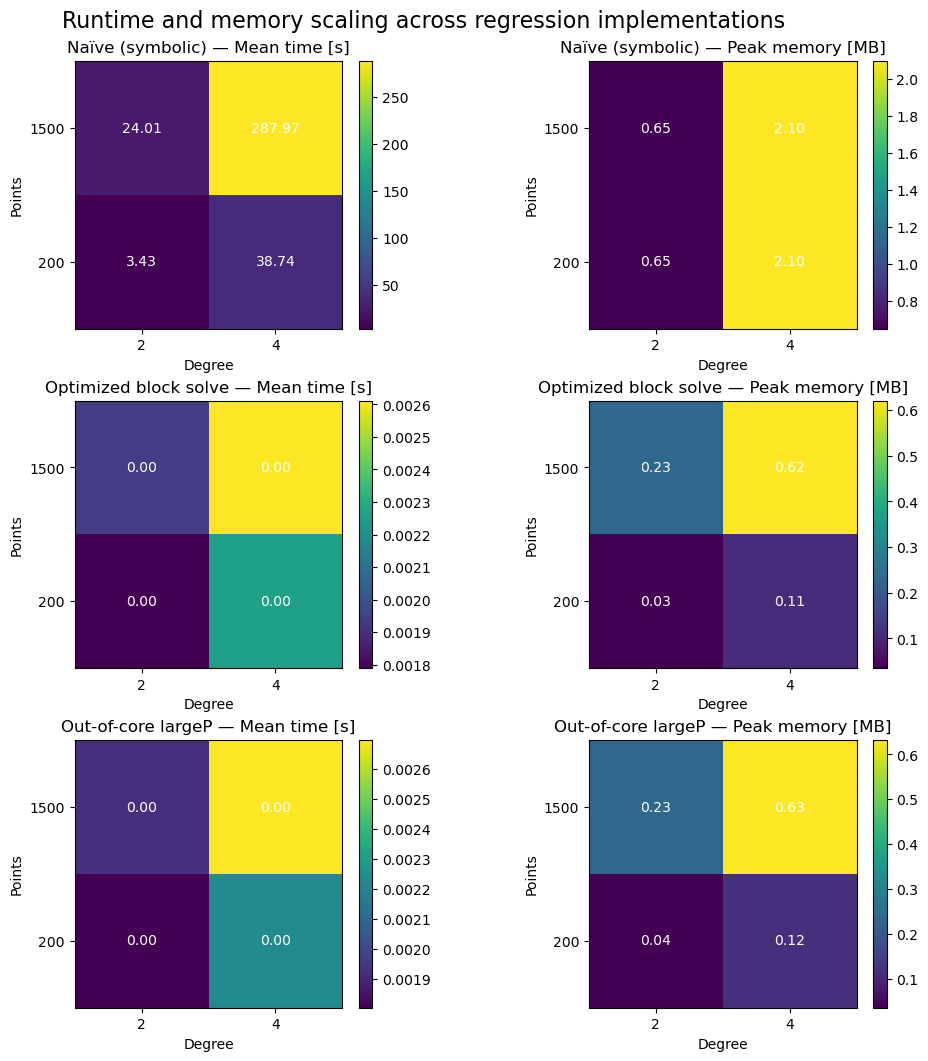

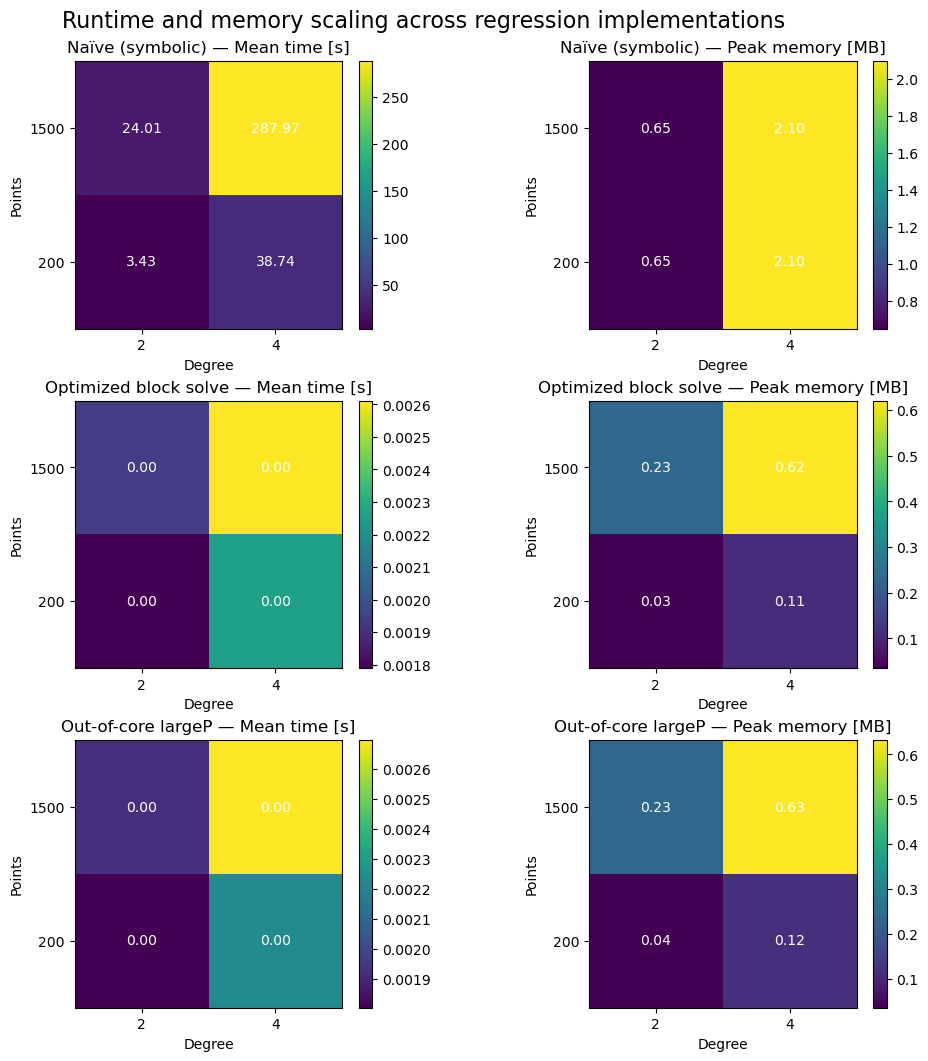

In [7]:
if 'df' not in locals():
    import pandas as pd  # type: ignore[no-redef]
    df = pd.DataFrame(records_table)

impl_order = list(IMPLEMENTATIONS.keys())
points = sorted(set(df['Points']))
degrees = sorted(set(df['Degree']))

fig, axes = plt.subplots(len(impl_order), 2, figsize=(10, 3.5 * len(impl_order)), constrained_layout=True)
for i, name in enumerate(impl_order):
    subset = df[df['Implementation'] == name]
    time_grid = np.zeros((len(points), len(degrees)))
    mem_grid = np.zeros_like(time_grid)
    for _, row in subset.iterrows():
        pi = points.index(row['Points'])
        di = degrees.index(row['Degree'])
        time_grid[pi, di] = row['Mean time [s]']
        mem_grid[pi, di] = row['Peak memory [MB]']

    for ax, grid, label in zip(axes[i], (time_grid, mem_grid), ('Mean time [s]', 'Peak memory [MB]')):
        im = ax.imshow(grid, origin='lower', cmap='viridis')
        ax.set_xticks(range(len(degrees)), degrees)
        ax.set_yticks(range(len(points)), points)
        ax.set_xlabel('Degree')
        ax.set_ylabel('Points')
        ax.set_title(f'{name} — {label}')
        for (y, x), value in np.ndenumerate(grid):
            ax.text(x, y, f'{value:.2f}', ha='center', va='center', color='white', fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Runtime and memory scaling across regression implementations', fontsize=16)
fig

## Large-scale benchmark
To stress-test the memory optimizations, we benchmark the two tuned implementations on a much larger dataset.

In [6]:
LARGE_POINTS = 20000
LARGE_DEGREE = 3
HIGH_LOAD_IMPLEMENTATIONS = {
    'Optimized block solve': IMPLEMENTATIONS['Optimized block solve'],
    'Out-of-core largeP': IMPLEMENTATIONS['Out-of-core largeP'],
}

X_large, Y_large = make_dataset(LARGE_POINTS)
large_repeat = 2
large_records: list[dict[str, float | int | str]] = []
for name, func in HIGH_LOAD_IMPLEMENTATIONS.items():
    mean_t, std_t, mean_mem = benchmark(func, X_large, Y_large, LARGE_DEGREE, repeat=large_repeat)
    large_records.append({
        'Implementation': name,
        'Points': LARGE_POINTS,
        'Degree': LARGE_DEGREE,
        'Repeat': large_repeat,
        'Mean time [s]': mean_t,
        'Std time [s]': std_t,
        'Peak memory [MB]': mean_mem,
    })

if pd is not None:
    display(pd.DataFrame(large_records))
else:
    for rec in large_records:
        msg = (
            f"{rec['Implementation']}: time={rec['Mean time [s]']:.3f}s "
            f"±{rec['Std time [s]']:.3f}s, peak={rec['Peak memory [MB]']:.2f} MB"
        )
        print(msg)

large_records


,Implementation,Points,Degree,Repeat,Mean time [s],Std time [s],Peak memory [MB]
0,Optimized block solve,20000,3,2,0.007176,0.001181,3.400716
1,Out-of-core largeP,20000,3,2,0.006668,0.000045,1.712732


[{'Implementation': 'Optimized block solve',
  'Points': 20000,
  'Degree': 3,
  'Repeat': 2,
  'Mean time [s]': 0.007176481500209775,
  'Std time [s]': 0.001180658499833953,
  'Peak memory [MB]': 3.400716},
 {'Implementation': 'Out-of-core largeP',
  'Points': 20000,
  'Degree': 3,
  'Repeat': 2,
  'Mean time [s]': 0.006667593000202032,
  'Std time [s]': 4.4768999941879883e-05,
  'Peak memory [MB]': 1.712732}]

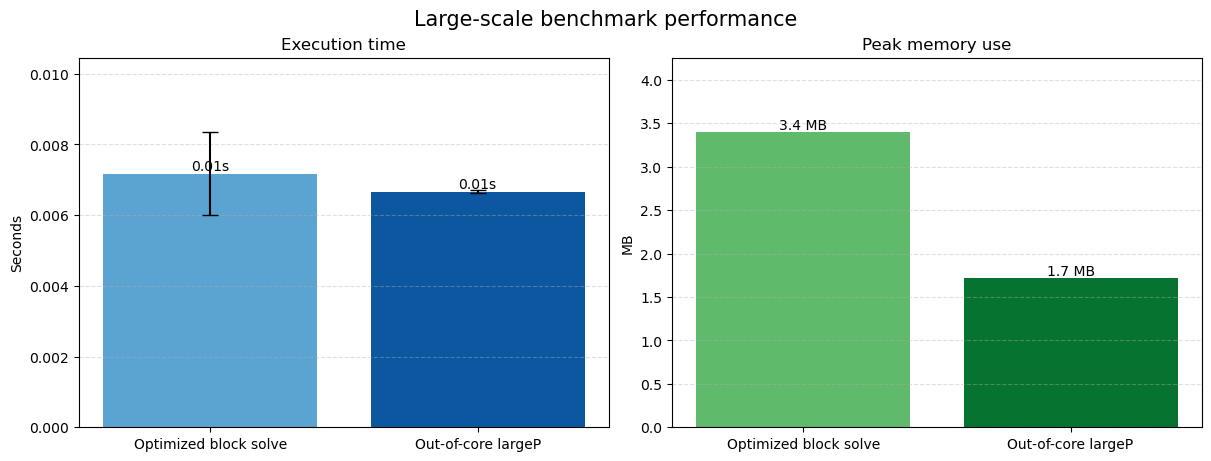

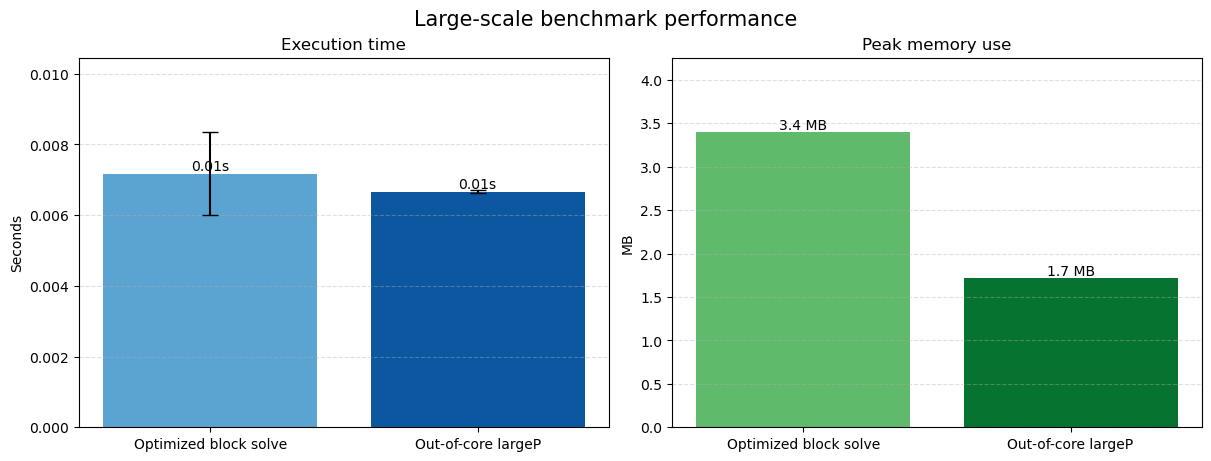

In [7]:
labels = list(HIGH_LOAD_IMPLEMENTATIONS.keys())
large_summary = {rec['Implementation']: rec for rec in large_records}
means = np.array([large_summary[name]['Mean time [s]'] for name in labels], dtype=float)
stds = np.array([large_summary[name]['Std time [s]'] for name in labels], dtype=float)
mems = np.array([large_summary[name]['Peak memory [MB]'] for name in labels], dtype=float)

if pd is not None:
    large_df = pd.DataFrame([large_summary[name] for name in labels])
else:
    large_df = large_summary

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

bars_time = axes[0].bar(
    labels,
    means,
    yerr=stds,
    color=plt.cm.Blues(np.linspace(0.55, 0.85, len(labels))),
    capsize=6,
)
axes[0].set_title('Execution time')
axes[0].set_ylabel('Seconds')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
max_time = float(np.max(means + stds)) if np.any(means + stds) else float(np.max(means) if np.any(means) else 1.0)
axes[0].set_ylim(0, max_time * 1.25)
for bar, mean in zip(bars_time, means):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{mean:.2f}s',
        ha='center',
        va='bottom',
        fontsize=10,
    )

bars_mem = axes[1].bar(
    labels,
    mems,
    color=plt.cm.Greens(np.linspace(0.55, 0.85, len(labels))),
)
axes[1].set_title('Peak memory use')
axes[1].set_ylabel('MB')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
max_mem = float(np.max(mems)) if np.any(mems) else 1.0
axes[1].set_ylim(0, max_mem * 1.25)
for bar, mem in zip(bars_mem, mems):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{mem:.1f} MB',
        ha='center',
        va='bottom',
        fontsize=10,
    )

fig.suptitle('Large-scale benchmark performance', fontsize=15)
fig